# Import

|CD | Fibre | Sweep | ID | 
|---|---|---|---|
|5 | White | None | N/A | 
|6 | Beige | Warming | 69 | 
|7 | BF | Cooling | 5 | 
|7 | BF | Warming | 9 | 
|8 | BF Unclamped | Cooling | 9 | 

5: ID7-9 is RT measurements and 10-12 is 4K measurement 


In [9]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
from functions import quick_check
from functions import calibrate
import snspd

In [47]:
initialise_or_create_database_at("./2026-04-17_SNSPD5.db")
params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd5-1.yaml')

# Set up experiment
exp_name = 'SNSPD5'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

2026-04-29 11:20:07,387 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ <>:2: SyntaxWarning: invalid escape sequence '\S'

2026-04-29 11:20:07,388 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ <>:2: SyntaxWarning: invalid escape sequence '\S'

2026-04-29 11:20:07,390 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\AppData\Local\Temp\ipykernel_38648\3216661217.py:2: SyntaxWarning: invalid escape sequence '\S'
  params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd5-1.yaml')



Experiment loaded. Last ID no: 166


Cooldown 5 White Fibre RT results

|ID| Still Temp| Time|
|---|---|---|
|7| 295 | 18:15|
|8| 295 | 18:15|
|9| 295 | 18:15|
|10| 3.617 |10:30|
|11| 3.617 |10:30|
|12| 3.617 |10:30|

In [61]:
initialise_or_create_database_at("./2026-04-17_SNSPD5.db")
params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd5-1.yaml')

# Set up experiment
exp_name = 'SNSPD5'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

still_temp_RT = 295
power10_5_RT = []
att_5_RT = []

for ID in range(7,10): 
    data = load_by_id(ID).get_parameter_data()
    timestamp = load_by_id(ID).run_timestamp()
    connection = load_by_id(ID).metadata['attenuator_name']
    power10 = data['power10']['power10']
    power90 = data['power90']['power90']
    attenuation = data['attenuation']['attenuation']
    print(f'attenuation: {attenuation}')
    print(ID)
    print(connection)
    print(f'Time: {timestamp}')
    power_90pc_port = 0.00482118
    print(f'power10: {power10} (should be small, PM100USB disconnected)')
    print(f'power90: {power90}')
    print(f'Power at 90% port: {power_90pc_port}')
    expected = params.bs10*power_90pc_port/params.bs90
    print(f'Expected max power90: {expected}')
    print(f'Condition met? {'Yes' if power90 < expected else 'No'}')
    print('\n')
    
    power10_5_RT.append(power90)
    att_5_RT.append(attenuation)

t_still_5_RT = np.ones_like(power10_5_RT)*still_temp_RT


still_temp = 3.617
power10_5_fourk = []
att_5_fourk = []
for ID in [10, 11, 12]: 
    data = load_by_id(ID).get_parameter_data()
    timestamp = load_by_id(ID).run_timestamp()
    connection = load_by_id(ID).metadata['attenuator_name']
    power10 = data['power10']['power10']
    power90 = data['power90']['power90']

    print(ID)
    print(connection)
    print(f'Time: {timestamp}')
    power_90pc_port = 0.00482118
    print(f'power10: {power10} (should be small, PM100USB disconnected)')
    print(f'power90: {power90}')
    print(f'Assumed power at 90% port: {power_90pc_port}')
    expected = params.bs10*power_90pc_port/params.bs90
    print(f'Expected max power90: {expected}')
    print(f'Condition met? {'Yes' if power90 < expected else 'No'}')
    print('\n')

    power10_5_fourk.append(power90)

t_still_5_fourk = np.ones_like(power10_5_fourk)*still_temp

2026-04-29 11:27:40,993 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ <>:2: SyntaxWarning: invalid escape sequence '\S'

2026-04-29 11:27:40,996 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ <>:2: SyntaxWarning: invalid escape sequence '\S'

2026-04-29 11:27:40,998 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\AppData\Local\Temp\ipykernel_38648\3144778807.py:2: SyntaxWarning: invalid escape sequence '\S'
  params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd5-1.yaml')



Experiment loaded. Last ID no: 166
attenuation: [92.08385971]
7
ferrule to ferrule
Time: 2026-04-17 18:12:33
power10: [1.99510445e-14] (should be small, PM100USB disconnected)
power90: [0.00033329]
Power at 90% port: 0.00482118
Expected max power90: 0.00046631527958688297
Condition met? Yes


attenuation: [92.07597318]
8
ferrule to ferrule
Time: 2026-04-17 18:12:58
power10: [1.99510445e-14] (should be small, PM100USB disconnected)
power90: [0.00033269]
Power at 90% port: 0.00482118
Expected max power90: 0.00046631527958688297
Condition met? Yes


attenuation: [66.53237707]
9
ferrule to ferrule
Time: 2026-04-17 18:13:47
power10: [7.14247411e-12] (should be small, PM100USB disconnected)
power90: [0.00033232]
Power at 90% port: 0.00482118
Expected max power90: 0.00046631527958688297
Condition met? Yes


10
ferrule to ferrule
Time: 2026-04-20 10:27:57
power10: [7.14247411e-12] (should be small, PM100USB disconnected)
power90: [1.67331768e-06]
Assumed power at 90% port: 0.00482118
Expected 

2026-04-29 11:23:43,335 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ <>:5: SyntaxWarning: invalid escape sequence '\S'

2026-04-29 11:23:43,339 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ <>:5: SyntaxWarning: invalid escape sequence '\S'

2026-04-29 11:23:43,341 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\AppData\Local\Temp\ipykernel_38648\3230796980.py:5: SyntaxWarning: invalid escape sequence '\S'
  params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd7-1.yaml')



Experiment loaded. Last ID no: 9


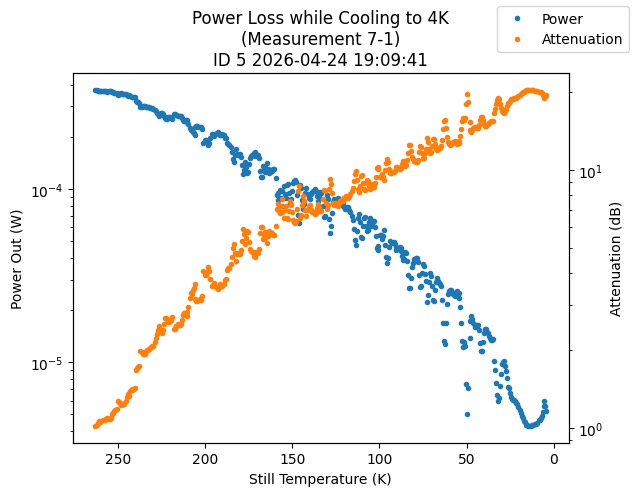

In [56]:
initialise_or_create_database_at("./2026-04-17_SNSPD7.db")
from functions import quick_check
from functions import calibrate
import snspd
params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd7-1.yaml')

# Set up experiment
exp_name = 'SNSPD7'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')
    
ID = 5
data_7 = load_by_id(ID).get_parameter_data()
power10_7 = data_7['power10']['power10']
power90_7 = data_7['power90']['power90']
attenuation_7 = data_7['attenuation']['attenuation']
still_temp_7 = data_7['still_temp']['still_temp']

fig, ax1 = plt.subplots()

ax1.semilogy(still_temp_7, power10_7, '.', label='Power')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.set_title(params.make_title('Power Loss while Cooling to 4K\n(Measurement 7-1)', ID))
ax1.invert_xaxis()

ax2 = ax1.twinx()
ax2.semilogy(still_temp_7, attenuation_7, '.', color='tab:orange', label='Attenuation') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')
fig.legend()


# Cooldown 8 Data

2026-04-29 11:48:36,914 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ <>:5: SyntaxWarning: invalid escape sequence '\S'

2026-04-29 11:48:36,916 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ <>:5: SyntaxWarning: invalid escape sequence '\S'

2026-04-29 11:48:36,919 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\AppData\Local\Temp\ipykernel_38648\4267159051.py:5: SyntaxWarning: invalid escape sequence '\S'
  params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd8-1.yaml')



Experiment loaded. Last ID no: 9


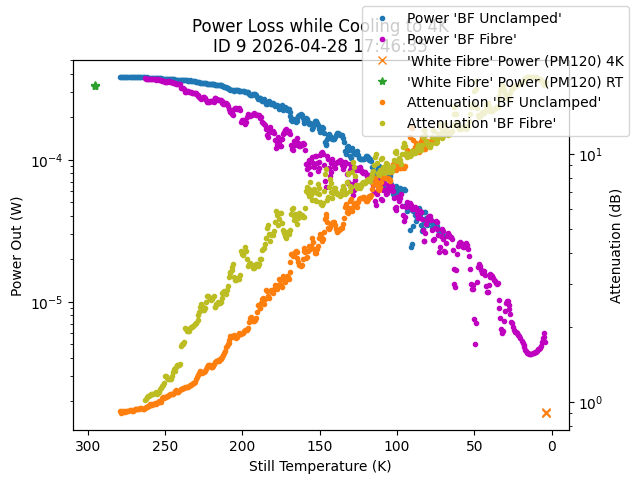

In [73]:
initialise_or_create_database_at("./2026-04-17_SNSPD8.db")
from functions import quick_check
from functions import calibrate
import snspd
params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd8-1.yaml')

# Set up experiment
exp_name = 'SNSPD8'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')
    
ID = 9
data = load_by_id(ID).get_parameter_data()
power10 = data['power10']['power10']
power90 = data['power90']['power90']
attenuation = data['attenuation']['attenuation']
still_temp = data['still_temp']['still_temp']

fig, ax1 = plt.subplots()

ax1.semilogy(still_temp, power10, '.', label='Power \'BF Unclamped\'')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.set_title(params.make_title('Power Loss while Cooling to 4K', ID))
ax1.invert_xaxis()

ax2 = ax1.twinx()
ax2.semilogy(still_temp, attenuation, '.', color='tab:orange', label='Attenuation \'BF Unclamped\'') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')

ax1.semilogy(still_temp_7, power10_7, '.', color = 'm', label='Power \'BF Fibre\'')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')

ax2.semilogy(still_temp_7, attenuation_7, '.', color='tab:olive', label='Attenuation \'BF Fibre\'') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')


ax1.semilogy(t_still_5_fourk, power10_5_fourk, 'x', label='\'White Fibre\' Power (PM120) 4K')
ax1.semilogy(t_still_5_RT, power10_5_RT, '*', label='\'White Fibre\' Power (PM120) RT')

# ax2.semilogy(t_still_5_fourk, att_5_fourk, 'x', label = '5-1 Attenuation (PM120) 4K')
# ax2.semilogy(t_still_5_RT, att_5_RT, '*', label = '5-1 Attenuation (PM120) RT')

fig.legend()



# Warming

2026-04-29 11:37:04,780 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ <>:5: SyntaxWarning: invalid escape sequence '\S'

2026-04-29 11:37:04,781 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ <>:44: SyntaxWarning: invalid escape sequence '\S'

2026-04-29 11:37:04,783 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ <>:5: SyntaxWarning: invalid escape sequence '\S'

2026-04-29 11:37:04,784 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ <>:44: SyntaxWarning: invalid escape sequence '\S'

2026-04-29 11:37:04,786 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\AppData\Local\Temp\ipykernel_38648\816824367.py:5: SyntaxWarning: invalid escape sequence '\S'
  params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd7-1.yaml')

2026-04-29 11:37:04,788 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\AppData\Local\Temp\ipykernel_38648\816824367.py:44: SyntaxWarning: invalid escape sequence '\S'
  params = snspd.snsp

Experiment loaded. Last ID no: 9
Experiment loaded. Last ID no: 69


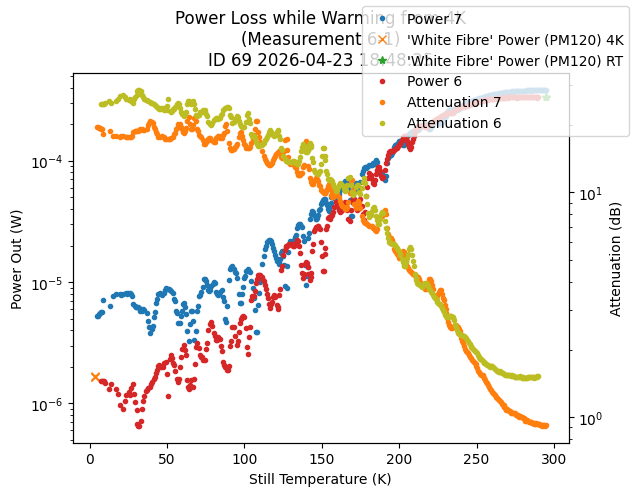

In [72]:
initialise_or_create_database_at("./2026-04-17_SNSPD7.db")
from functions import quick_check
from functions import calibrate
import snspd
params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd7-1.yaml')

# Set up experiment
exp_name = 'SNSPD7'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

ID = 9
data = load_by_id(ID).get_parameter_data()
power10 = data['power10']['power10']
power90 = data['power90']['power90']
attenuation = data['attenuation']['attenuation']
still_temp = data['still_temp']['still_temp']

fig, ax1 = plt.subplots()

ax1.semilogy(still_temp, power10, '.', label='Power 7')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.set_title(params.make_title('Power Loss while Warming from 4K\n(Measurement 7-1)', ID))

ax2 = ax1.twinx()
ax2.semilogy(still_temp, attenuation, '.', color='tab:orange', label='Attenuation 7') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')

# ID 5 results
ax1.semilogy(t_still_5_fourk, power10_5_fourk, 'x', label='\'White Fibre\' Power (PM120) 4K')
ax1.semilogy(t_still_5_RT, power10_5_RT, '*', label='\'White Fibre\' Power (PM120) RT')

# ID 6 
initialise_or_create_database_at("./2026-04-17_SNSPD6.db")
import snspd
params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd6-1.yaml')

# Set up experiment
exp_name = 'SNSPD6'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

ID = 69
data = load_by_id(ID).get_parameter_data()
power10 = data['power10']['power10']
power90 = data['power90']['power90']
attenuation = data['attenuation']['attenuation']
still_temp = data['still_temp']['still_temp']

ax1.semilogy(still_temp, power10, '.', label='Power 6')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.set_title(params.make_title('Power Loss while Warming from 4K\n(Measurement 6-1)', ID))
# ax1.invert_xaxis()

ax2.semilogy(still_temp, attenuation, '.', color='tab:olive', label='Attenuation 6') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')

fig.legend()


# OLD

Through optical breakout

In [11]:
ID = 1 
data = load_by_id(ID).get_parameter_data()
power10 = data['power10']['power10']
power90 = data['power90']['power90']
attenuation = data['attenuation']['attenuation']

print(f'Power90: {power90[0]}') 
print(f'Power10: {power10[0]}')
print(f'Atttenuation: {attenuation[0]}')

Power90: 0.00488496805
Power10: 0.000297434075
Atttenuation: 2.00997306148436


Through feedthrough

In [12]:
for ID in range(2, 5):
    data = load_by_id(ID).get_parameter_data()
    power10 = data['power10']['power10']
    power90 = data['power90']['power90']
    attenuation = data['attenuation']['attenuation']
    
    print(f'Power90: {power90[0]}') 
    print(f'Power10: {power10[0]}')
    print(f'Atttenuation: {attenuation[0]}')

Power90: 0.00489019789
Power10: 0.000384206738
Atttenuation: 0.902877567037519
Power90: 0.00484941667
Power10: 0.000381087535
Atttenuation: 0.901910571485299
Power90: 0.00485778181
Power10: 0.000381557213
Atttenuation: 0.904046361853094


Cooling with Feedthrough

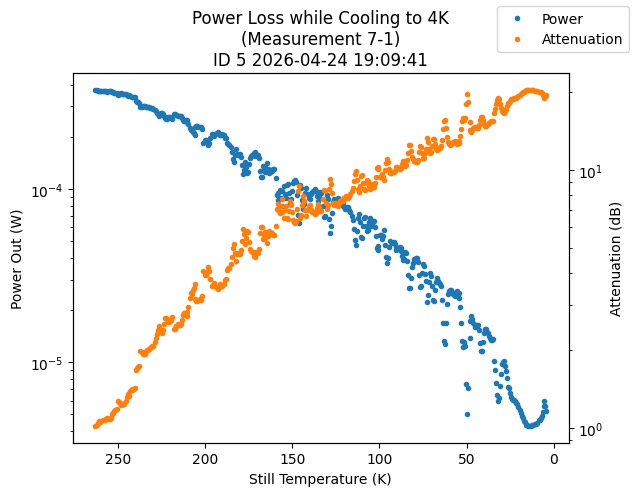

In [47]:
ID = 5
data = load_by_id(ID).get_parameter_data()
power10 = data['power10']['power10']
power90 = data['power90']['power90']
attenuation = data['attenuation']['attenuation']
still_temp = data['still_temp']['still_temp']

fig, ax1 = plt.subplots()

ax1.semilogy(still_temp, power10, '.', label='Power')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.set_title(params.make_title('Power Loss while Cooling to 4K\n(Measurement 7-1)', ID))
ax1.invert_xaxis()

ax2 = ax1.twinx()
ax2.semilogy(still_temp, attenuation, '.', color='tab:orange', label='Attenuation') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')
fig.legend()


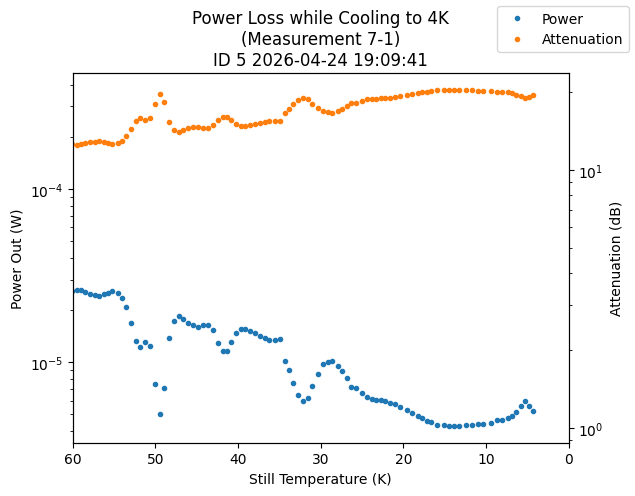

In [48]:
ID = 5
data = load_by_id(ID).get_parameter_data()
power10 = data['power10']['power10']
power90 = data['power90']['power90']
attenuation = data['attenuation']['attenuation']
still_temp = data['still_temp']['still_temp']

fig, ax1 = plt.subplots()

ax1.semilogy(still_temp, power10, '.', label='Power')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.set_title(params.make_title('Power Loss while Cooling to 4K\n(Measurement 7-1)', ID))
ax1.set_xlim([0, 60])
ax1.invert_xaxis()

ax2 = ax1.twinx()
ax2.semilogy(still_temp, attenuation, '.', color='tab:orange', label='Attenuation') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')
fig.legend()


At 4K 

In [52]:
for ID in range(6, 9):
    data = load_by_id(ID).get_parameter_data()
    power10 = data['power10']['power10']
    power90 = data['power90']['power90']
    attenuation = data['attenuation']['attenuation']
    
    print(f'Power90: {power90[0]}') 
    print(f'Power10: {power10[0]}')
    print(f'Atttenuation: {attenuation[0]}')

Power90: 0.00487660291
Power10: 5.15432885e-06
Atttenuation: 19.6147156984979
Power90: 0.00487451162
Power10: 5.20487492e-06
Atttenuation: 19.5704711248579
Power90: 0.00486928364
Power10: 5.20051117e-06
Atttenuation: 19.569453395722


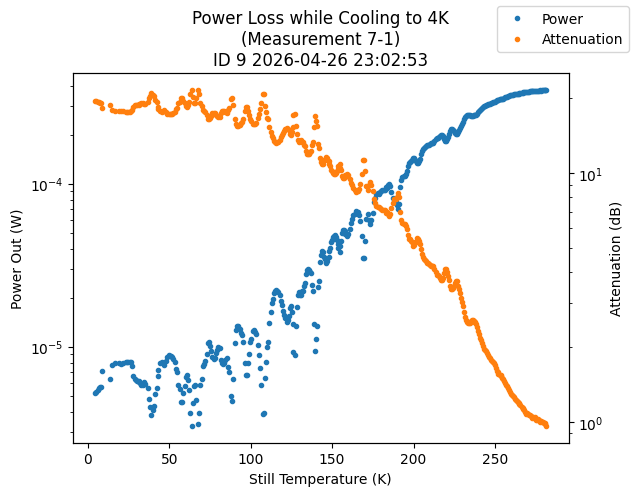

In [53]:
ID = 9
data = load_by_id(ID).get_parameter_data()
power10 = data['power10']['power10']
power90 = data['power90']['power90']
attenuation = data['attenuation']['attenuation']
still_temp = data['still_temp']['still_temp']

fig, ax1 = plt.subplots()

ax1.semilogy(still_temp, power10, '.', label='Power')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.set_title(params.make_title('Power Loss while Cooling to 4K\n(Measurement 7-1)', ID))

ax2 = ax1.twinx()
ax2.semilogy(still_temp, attenuation, '.', color='tab:orange', label='Attenuation') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')
fig.legend()
